In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings, os
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

SENT_ORDER   = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
SENT_COLORS  = ["#c0392b", "#e67e22", "#7f8c8d", "#2980b9", "#1abc9c"]
SENT_PALETTE = dict(zip(SENT_ORDER, SENT_COLORS))

In [2]:
trades_raw = pd.read_csv("historical_data.csv")
fg_raw     = pd.read_csv("fear_greed_index.csv")

print("Trades shape :", trades_raw.shape)
print("FG shape     :", fg_raw.shape)

Trades shape : (211224, 16)
FG shape     : (2644, 4)


In [3]:
trades = trades_raw.copy()
fg     = fg_raw.copy()

trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")
fg.columns     = fg.columns.str.strip().str.lower().str.replace(" ", "_")

# ── Date parsing ──────────────────────────────────────────
trades["date"] = pd.to_datetime(trades["timestamp"], unit="ms").dt.normalize()
fg["date"]     = pd.to_datetime(fg["date"]).dt.normalize()

# ── Fee-adjusted PnL (true profit) ───────────────────────
trades["net_pnl"] = trades["closed_pnl"] - trades["fee"].fillna(0)

# ── Outlier capping (IQR winsorize on net_pnl) ───────────
q1, q3 = trades["net_pnl"].quantile([0.01, 0.99])
trades["net_pnl_capped"] = trades["net_pnl"].clip(q1, q3)

# ── Basic flags ───────────────────────────────────────────
trades["win"]         = trades["net_pnl"] > 0
trades["side_binary"] = (trades["side"].str.upper() == "BUY").astype(int)

# ── Drop nulls ────────────────────────────────────────────
trades.dropna(subset=["net_pnl"], inplace=True)
trades.drop_duplicates(inplace=True)
fg.drop_duplicates(subset=["date"], inplace=True)

# ── Sentiment streaks (consecutive same-label days) ───────
fg_sorted = fg.sort_values("date").copy()
fg_sorted["prev_class"] = fg_sorted["classification"].shift(1)
fg_sorted["streak_day"] = (fg_sorted["classification"] == fg_sorted["prev_class"]).astype(int)
fg_sorted["streak_id"]  = (fg_sorted["classification"] != fg_sorted["prev_class"]).cumsum()
fg_sorted["streak_len"] = fg_sorted.groupby("streak_id")["streak_id"].transform("count")

# ── Merge sentiment onto trades ───────────────────────────
df = trades.merge(
    fg_sorted[["date","classification","streak_len"]],
    on="date", how="left"
)
df.dropna(subset=["classification"], inplace=True)
df["classification"] = pd.Categorical(
    df["classification"], categories=SENT_ORDER, ordered=True
)

# ── Day-of-week feature ───────────────────────────────────
df["day_of_week"] = pd.to_datetime(df["date"]).dt.dayofweek
df["is_weekend"]  = df["day_of_week"].isin([5, 6]).astype(int)

print(f"Final shape  : {df.shape}")
print(f"Unique traders: {df['account'].nunique():,}")
print(f"Date range   : {df['date'].min()} to {df['date'].max()}")
print("\nTrades per sentiment:")
print(df["classification"].value_counts().reindex(SENT_ORDER))

Final shape  : (184263, 25)
Unique traders: 32
Date range   : 2023-03-28 00:00:00 to 2025-02-19 00:00:00

Trades per sentiment:
classification
Extreme Fear          0
Fear             133871
Neutral            7141
Greed             36289
Extreme Greed      6962
Name: count, dtype: int64


In [4]:
def profit_factor(series):
    gains  = series[series > 0].sum()
    losses = abs(series[series < 0].sum())
    return round(gains / losses, 3) if losses != 0 else np.nan

perf = df.groupby("classification", observed=True).agg(
    avg_net_pnl    = ("net_pnl",        "mean"),
    median_net_pnl = ("net_pnl",        "median"),
    total_net_pnl  = ("net_pnl",        "sum"),
    win_rate       = ("win",            "mean"),
    trade_count    = ("net_pnl",        "count"),
    avg_size_usd   = ("size_usd",       "mean"),
    long_ratio     = ("side_binary",    "mean"),
    avg_streak_len = ("streak_len",     "mean"),
    avg_fee        = ("fee",            "mean"),
).reindex(SENT_ORDER).round(3)

perf["win_rate_pct"] = (perf["win_rate"] * 100).round(1)
perf["long_pct"]     = (perf["long_ratio"] * 100).round(1)

# Profit factor per sentiment
pf = df.groupby("classification", observed=True)["net_pnl"].apply(profit_factor)
perf["profit_factor"] = pf.reindex(SENT_ORDER)

print("Performance Summary (Fee-Adjusted):")
print(perf[[
    "avg_net_pnl","win_rate_pct","profit_factor",
    "long_pct","avg_size_usd","trade_count"
]].to_string())

perf.to_csv("outputs/sentiment_performance_summary.csv")

# Mann-Whitney U test
fear_pnl  = df[df["classification"].isin(["Extreme Fear","Fear"])]["net_pnl"]
greed_pnl = df[df["classification"].isin(["Greed","Extreme Greed"])]["net_pnl"]
u_stat, p_val = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative="greater")
print(f"\nMann-Whitney U: U={u_stat:.0f},  p={p_val:.4f}")
print("Statistically significant." if p_val < 0.05 else "Not significant at 0.05 level.")

# Kruskal-Wallis across all 5 groups
groups = [df[df["classification"]==s]["net_pnl"].values for s in SENT_ORDER]
h_stat, kw_p = stats.kruskal(*groups)
print(f"Kruskal-Wallis (all groups): H={h_stat:.2f},  p={kw_p:.4f}")

Performance Summary (Fee-Adjusted):
                avg_net_pnl  win_rate_pct  profit_factor  long_pct  avg_size_usd  trade_count
classification                                                                               
Extreme Fear            NaN           NaN            NaN       NaN           NaN          NaN
Fear                 48.964          41.1          5.582      49.4      5259.978     133871.0
Neutral              21.005          31.4          1.881      49.1      3058.848       7141.0
Greed                87.224          44.7          7.012      42.5      3182.884      36289.0
Extreme Greed        24.440          56.5          3.006      48.4      5660.266       6962.0

Mann-Whitney U: U=2712941181,  p=1.0000
Not significant at 0.05 level.
Kruskal-Wallis (all groups): H=nan,  p=nan


Avg PnL by Coin & Sentiment:
classification  Extreme Fear    Fear  Neutral    Greed  Extreme Greed
coin                                                                 
@107                     NaN   13.60      NaN   188.86            NaN
@123                     NaN     NaN      NaN    -0.03            NaN
@142                     NaN   14.10      NaN      NaN            NaN
@4                       NaN   -0.02     2.46    -8.53            NaN
@51                      NaN   -0.22   -11.56    -1.07            NaN
@8                       NaN     NaN    -0.67    -2.68            NaN
@85                      NaN  132.42      NaN   282.66            NaN
AAVE                     NaN    5.99     1.84    38.92        -115.85
ADA                      NaN  -87.51      NaN     5.41            NaN
AI16Z                    NaN   14.83      NaN      NaN            NaN
AIXBT                    NaN   53.41      NaN      NaN            NaN
ALT                      NaN   25.82      NaN      NaN       

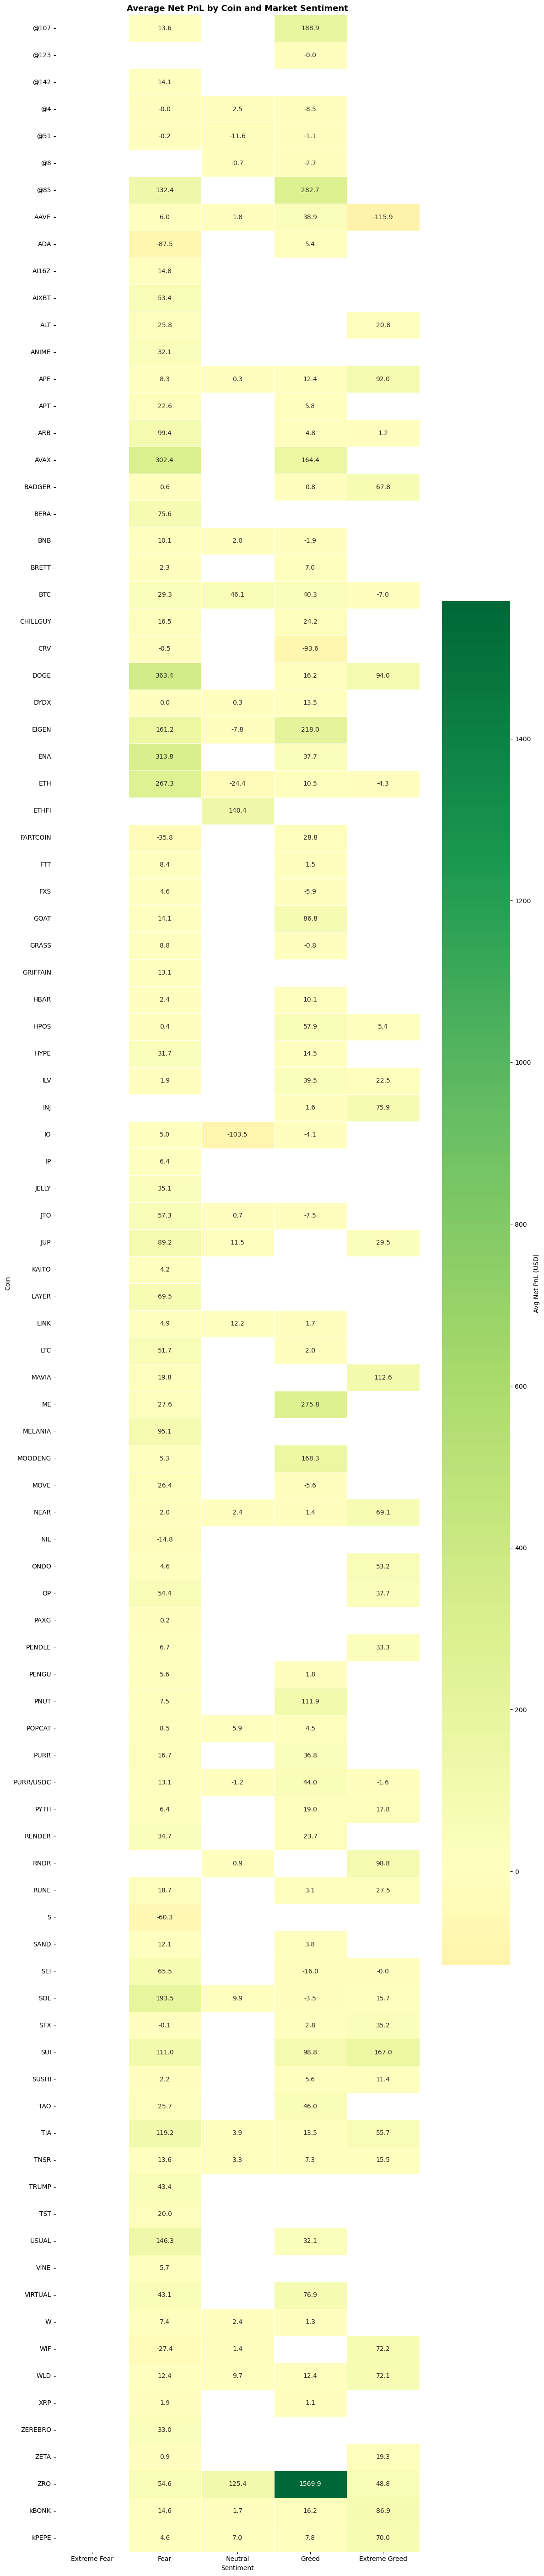

In [5]:
# Which coins perform best under which sentiment?
coin_sent = df.groupby(["coin","classification"], observed=True).agg(
    avg_pnl    = ("net_pnl",  "mean"),
    win_rate   = ("win",      "mean"),
    trade_count= ("net_pnl",  "count"),
).reset_index()

# Keep only coins with enough data
valid_coins = coin_sent.groupby("coin")["trade_count"].sum()
valid_coins = valid_coins[valid_coins >= 100].index
coin_sent   = coin_sent[coin_sent["coin"].isin(valid_coins)]

pivot_pnl = coin_sent.pivot(
    index="coin", columns="classification", values="avg_pnl"
).reindex(columns=SENT_ORDER)

print("Avg PnL by Coin & Sentiment:")
print(pivot_pnl.round(2).to_string())
pivot_pnl.to_csv("outputs/coin_sentiment_pnl.csv")

fig, ax = plt.subplots(figsize=(12, max(5, len(valid_coins) * 0.6)))
sns.heatmap(
    pivot_pnl, annot=True, fmt=".1f", cmap="RdYlGn",
    linewidths=0.4, ax=ax, center=0,
    cbar_kws={"label": "Avg Net PnL (USD)"}
)
ax.set_title("Average Net PnL by Coin and Market Sentiment",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Coin")
plt.tight_layout()
plt.savefig("outputs/chart0_coin_sentiment_heatmap.png", bbox_inches="tight")
plt.show()

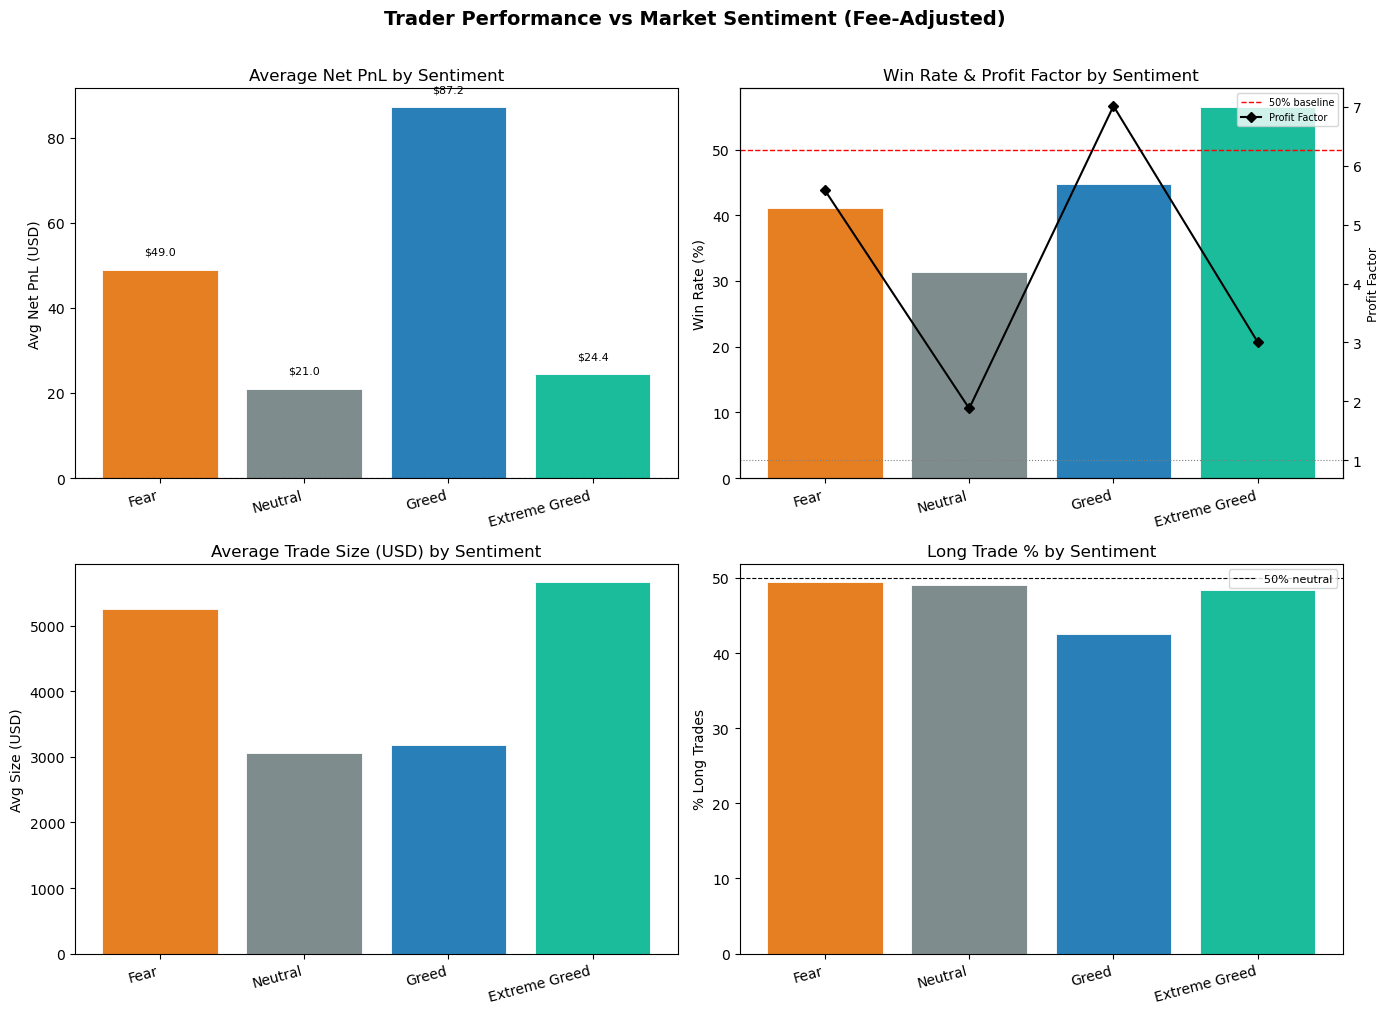

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Trader Performance vs Market Sentiment (Fee-Adjusted)",
             fontsize=14, fontweight="bold", y=1.01)
colors = [SENT_PALETTE[s] for s in SENT_ORDER]

# Chart 1 — Avg Net PnL
ax = axes[0][0]
bars = perf["avg_net_pnl"].reindex(SENT_ORDER)
ax.bar(SENT_ORDER, bars, color=colors, edgecolor="white", linewidth=0.6)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Average Net PnL by Sentiment")
ax.set_ylabel("Avg Net PnL (USD)")
ax.set_xticklabels(SENT_ORDER, rotation=15, ha="right")
offset = bars.abs().max() * 0.04
for i, v in enumerate(bars):
    ax.text(i, v + (offset if v >= 0 else -offset * 3),
            f"${v:.1f}", ha="center", fontsize=8)

# Chart 2 — Win Rate + Profit Factor
ax = axes[0][1]
wr = perf["win_rate_pct"].reindex(SENT_ORDER)
ax.bar(SENT_ORDER, wr, color=colors, edgecolor="white", linewidth=0.6)
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="50% baseline")
ax2 = ax.twinx()
ax2.plot(SENT_ORDER, perf["profit_factor"].reindex(SENT_ORDER),
         marker="D", color="black", linewidth=1.5, markersize=5, label="Profit Factor")
ax2.set_ylabel("Profit Factor", fontsize=9)
ax2.axhline(1.0, color="grey", linestyle=":", linewidth=0.8)
ax.set_title("Win Rate & Profit Factor by Sentiment")
ax.set_ylabel("Win Rate (%)")
ax.set_xticklabels(SENT_ORDER, rotation=15, ha="right")
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, fontsize=7, loc="upper right")

# Chart 3 — Avg Trade Size
ax = axes[1][0]
sz = perf["avg_size_usd"].reindex(SENT_ORDER)
ax.bar(SENT_ORDER, sz, color=colors, edgecolor="white", linewidth=0.6)
ax.set_title("Average Trade Size (USD) by Sentiment")
ax.set_ylabel("Avg Size (USD)")
ax.set_xticklabels(SENT_ORDER, rotation=15, ha="right")

# Chart 4 — Long %
ax = axes[1][1]
lp = perf["long_pct"].reindex(SENT_ORDER)
ax.bar(SENT_ORDER, lp, color=colors, edgecolor="white", linewidth=0.6)
ax.axhline(50, color="black", linestyle="--", linewidth=0.8, label="50% neutral")
ax.set_title("Long Trade % by Sentiment")
ax.set_ylabel("% Long Trades")
ax.set_xticklabels(SENT_ORDER, rotation=15, ha="right")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("outputs/chart1_core_performance.png", bbox_inches="tight")
plt.show()

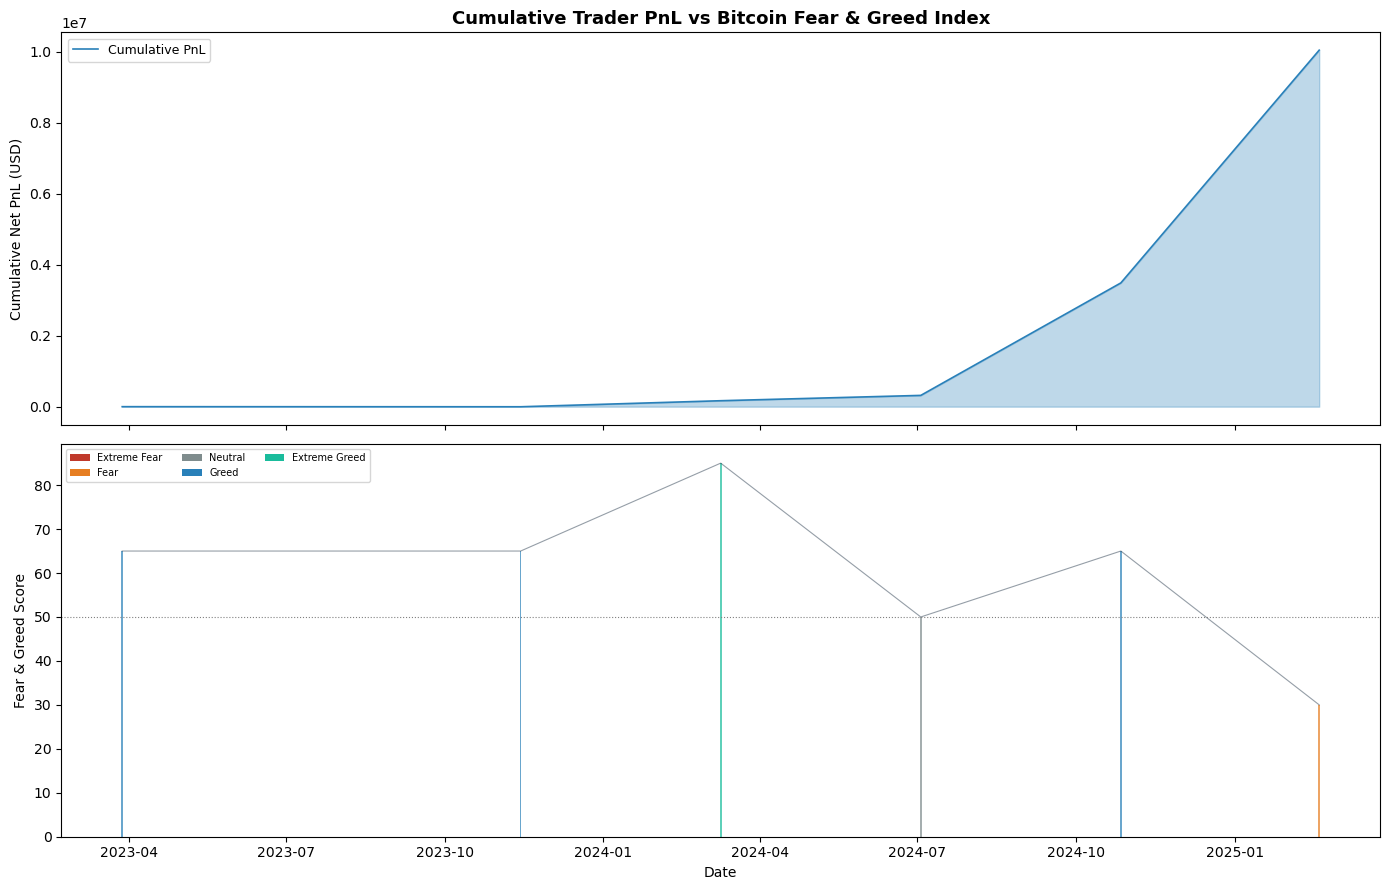

In [9]:
daily = df.groupby("date").agg(
    daily_pnl   = ("net_pnl",  "sum"),
    trade_count = ("net_pnl",  "count"),
    win_rate    = ("win",      "mean"),
).reset_index()

fg_score_map = {
    "Extreme Fear": 12, "Fear": 30,
    "Neutral": 50, "Greed": 65, "Extreme Greed": 85
}
daily = daily.merge(
    fg_sorted[["date","classification","streak_len"]], on="date", how="left"
)
daily["fg_score"] = daily["classification"].map(fg_score_map)
daily.sort_values("date", inplace=True)
daily["cumulative_pnl"] = daily["daily_pnl"].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1 = axes[0]
ax1.fill_between(daily["date"], daily["cumulative_pnl"],
                 alpha=0.3, color="#2980b9")
ax1.plot(daily["date"], daily["cumulative_pnl"],
         color="#2980b9", linewidth=1.2, label="Cumulative PnL")
ax1.set_ylabel("Cumulative Net PnL (USD)")
ax1.set_title("Cumulative Trader PnL vs Bitcoin Fear & Greed Index",
              fontsize=13, fontweight="bold")
ax1.legend(fontsize=9)

ax2 = axes[1]
bg_colors = [SENT_PALETTE.get(c, "#7f8c8d") for c in daily["classification"]]
ax2.bar(daily["date"], daily["fg_score"],
        color=bg_colors, width=1, alpha=0.7, label="Sentiment")
ax2.plot(daily["date"], daily["fg_score"],
         color="#2c3e50", linewidth=0.8, alpha=0.5)
ax2.axhline(50, color="grey", linestyle=":", linewidth=0.8)
ax2.set_ylabel("Fear & Greed Score")
ax2.set_xlabel("Date")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=SENT_PALETTE[s], label=s) for s in SENT_ORDER]
ax2.legend(handles=legend_elements, fontsize=7, loc="upper left", ncol=3)

plt.tight_layout()
plt.savefig("outputs/chart2_timeseries.png", bbox_inches="tight")
plt.show()

In [10]:
# Per-trader rolling features
df_sorted = df.sort_values(["account","date"])

# Rolling 30-day win rate per trader (requires enough history)
def rolling_win_rate(group):
    return group["win"].rolling(30, min_periods=5).mean()

df_sorted["roll_win_rate_30d"] = (
    df_sorted.groupby("account", group_keys=False)
    .apply(rolling_win_rate)
)

# Build trader feature matrix
trader_stats = df_sorted.groupby("account").agg(
    total_pnl         = ("net_pnl",           "sum"),
    win_rate          = ("win",               "mean"),
    avg_size_usd      = ("size_usd",          "mean"),
    trade_count       = ("net_pnl",           "count"),
    pnl_volatility    = ("net_pnl",           "std"),     # consistency metric
    fear_trade_pct    = ("classification",
                          lambda x: x.isin(["Fear","Extreme Fear"]).mean()),
    greed_trade_pct   = ("classification",
                          lambda x: x.isin(["Greed","Extreme Greed"]).mean()),
    long_ratio        = ("side_binary",       "mean"),
    avg_fee_paid      = ("fee",               "mean"),
    weekend_trade_pct = ("is_weekend",        "mean"),
).dropna()

# Profit factor per trader
def trader_pf(series):
    gains  = series[series > 0].sum()
    losses = abs(series[series < 0].sum())
    return gains / losses if losses > 0 else np.nan

pf_per_trader = df_sorted.groupby("account")["net_pnl"].apply(trader_pf)
trader_stats["profit_factor"] = pf_per_trader
trader_stats.dropna(subset=["profit_factor"], inplace=True)

# Normalise pnl_volatility
trader_stats["pnl_volatility"] = trader_stats["pnl_volatility"].fillna(0)

FEATURES = [
    "win_rate", "avg_size_usd", "trade_count",
    "pnl_volatility", "fear_trade_pct", "greed_trade_pct",
    "long_ratio", "profit_factor", "weekend_trade_pct"
]

scaler = StandardScaler()
X = scaler.fit_transform(trader_stats[FEATURES])

# Silhouette analysis
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    sil_scores[k] = silhouette_score(X, km.fit_predict(X))

best_k = max(sil_scores, key=sil_scores.get)
print(f"Silhouette Scores: { {k: round(v,4) for k,v in sil_scores.items()} }")
print(f"Optimal K: {best_k}")

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
trader_stats["cluster"] = km_final.fit_predict(X)

cluster_profile = trader_stats.groupby("cluster").agg(
    traders          = ("total_pnl",       "count"),
    avg_total_pnl    = ("total_pnl",       "mean"),
    avg_win_rate     = ("win_rate",        "mean"),
    avg_profit_factor= ("profit_factor",   "mean"),
    avg_size_usd     = ("avg_size_usd",    "mean"),
    avg_trades       = ("trade_count",     "mean"),
    pnl_volatility   = ("pnl_volatility",  "mean"),
    fear_trade_pct   = ("fear_trade_pct",  "mean"),
    greed_trade_pct  = ("greed_trade_pct", "mean"),
).round(3)

print("\nCluster Profiles:")
print(cluster_profile.to_string())

# Auto-label
cluster_labels = {}
for c in range(best_k):
    row = cluster_profile.loc[c]
    if (row["avg_total_pnl"] > cluster_profile["avg_total_pnl"].median()
            and row["pnl_volatility"] < cluster_profile["pnl_volatility"].median()):
        cluster_labels[c] = "Disciplined Traders"
    elif row["avg_size_usd"] > cluster_profile["avg_size_usd"].quantile(0.75):
        cluster_labels[c] = "High-Volume Speculators"
    elif row["fear_trade_pct"] > cluster_profile["fear_trade_pct"].median():
        cluster_labels[c] = "Contrarian Buyers"
    elif row["greed_trade_pct"] > cluster_profile["greed_trade_pct"].median():
        cluster_labels[c] = "Momentum Followers"
    else:
        cluster_labels[c] = f"Mixed Cluster {c}"

trader_stats["cluster_label"] = trader_stats["cluster"].map(cluster_labels)
trader_stats.to_csv("outputs/trader_clusters.csv")
print("\nAssigned Labels:", cluster_labels)

  File "C:\Users\ragey\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\ragey\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ragey\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ragey\anaconda3\Lib\subprocess.

Silhouette Scores: {2: np.float64(0.238), 3: np.float64(0.2549), 4: np.float64(0.2456), 5: np.float64(0.2005), 6: np.float64(0.238), 7: np.float64(0.2717)}
Optimal K: 7

Cluster Profiles:
         traders  avg_total_pnl  avg_win_rate  avg_profit_factor  avg_size_usd  avg_trades  pnl_volatility  fear_trade_pct  greed_trade_pct
cluster                                                                                                                                    
0             10     318059.831         0.347             25.090      3472.984    7334.700         503.323           0.575            0.349
1              4     194192.679         0.442            921.318      2998.804     647.000        1449.521           0.608            0.333
2              2    1008590.499         0.406              6.308     12860.326    2476.000        3835.611           0.850            0.150
3             11     224150.803         0.396             35.996      5527.972    4239.909         487.060      

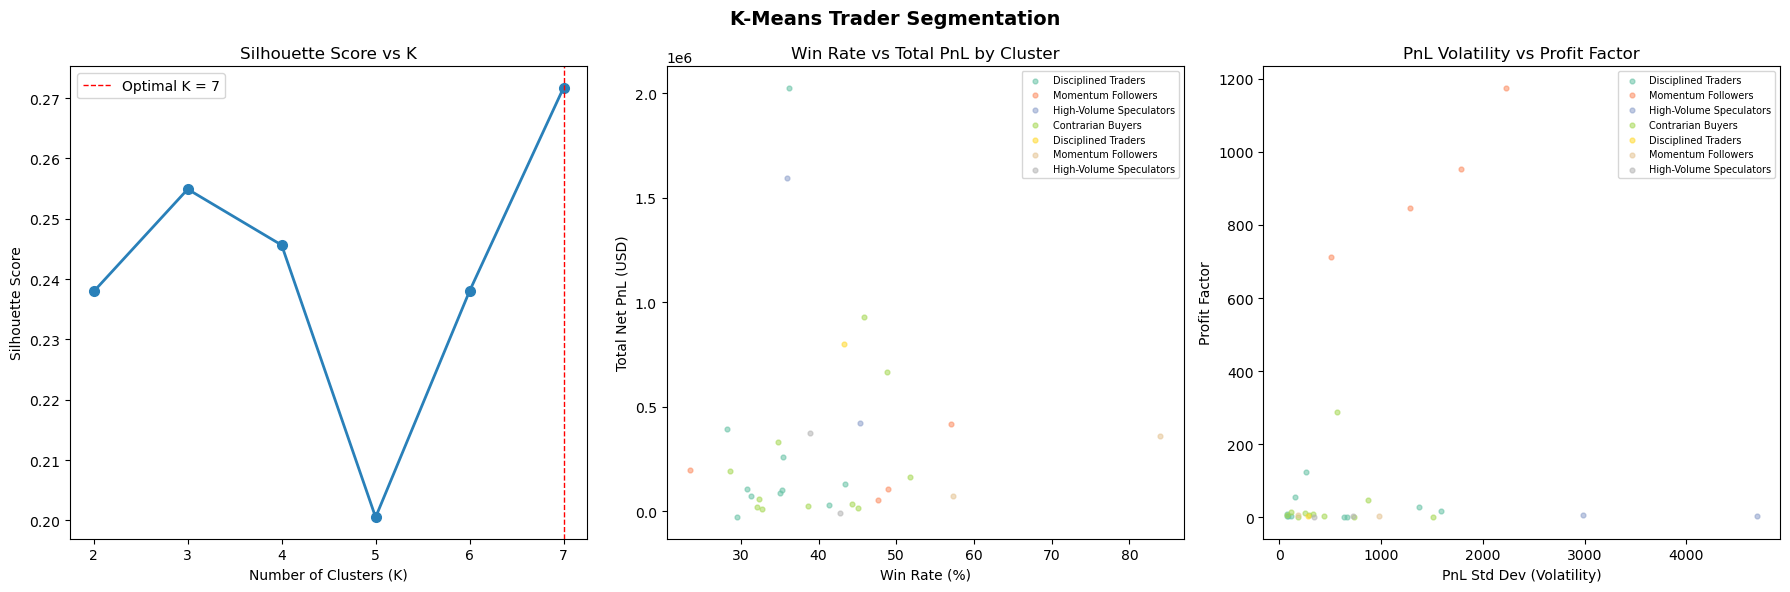

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Silhouette plot
ax = axes[0]
ax.plot(list(sil_scores.keys()), list(sil_scores.values()),
        marker="o", color="#2980b9", linewidth=2, markersize=7)
ax.axvline(best_k, color="red", linestyle="--", linewidth=1,
           label=f"Optimal K = {best_k}")
ax.set_title("Silhouette Score vs K")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.legend()

# Win Rate vs Total PnL scatter
ax = axes[1]
palette = plt.cm.Set2(np.linspace(0, 1, best_k))
for c in range(best_k):
    sub = trader_stats[trader_stats["cluster"] == c]
    ax.scatter(sub["win_rate"]*100, sub["total_pnl"],
               label=cluster_labels[c], alpha=0.55, s=12, color=palette[c])
ax.set_title("Win Rate vs Total PnL by Cluster")
ax.set_xlabel("Win Rate (%)")
ax.set_ylabel("Total Net PnL (USD)")
ax.legend(fontsize=7)

# Profit Factor vs PnL Volatility scatter
ax = axes[2]
for c in range(best_k):
    sub = trader_stats[trader_stats["cluster"] == c]
    ax.scatter(sub["pnl_volatility"], sub["profit_factor"],
               label=cluster_labels[c], alpha=0.55, s=12, color=palette[c])
ax.set_title("PnL Volatility vs Profit Factor")
ax.set_xlabel("PnL Std Dev (Volatility)")
ax.set_ylabel("Profit Factor")
ax.legend(fontsize=7)

plt.suptitle("K-Means Trader Segmentation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/chart3_kmeans_clusters.png", bbox_inches="tight")
plt.show()


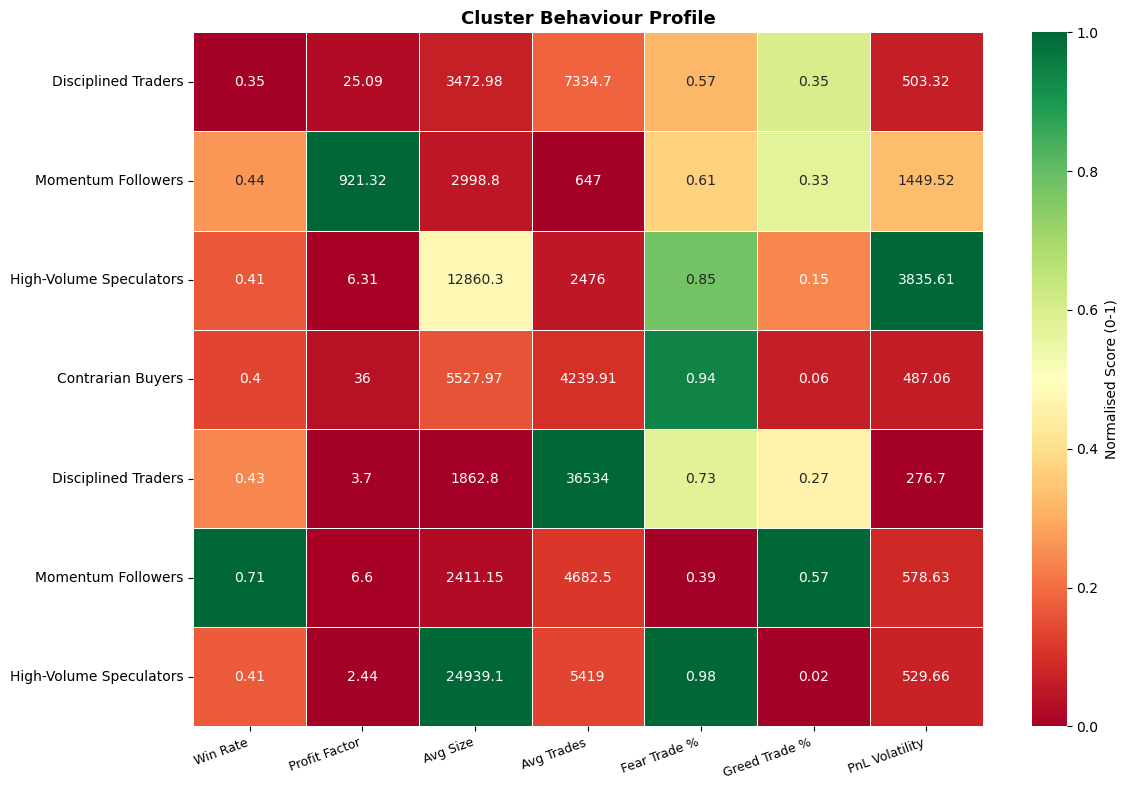

In [12]:
heatmap_cols = [
    "avg_win_rate","avg_profit_factor","avg_size_usd",
    "avg_trades","fear_trade_pct","greed_trade_pct","pnl_volatility"
]
heatmap_data = cluster_profile[heatmap_cols].copy()
heatmap_data.index = [cluster_labels[c] for c in heatmap_data.index]
heatmap_norm = (
    (heatmap_data - heatmap_data.min()) /
    (heatmap_data.max() - heatmap_data.min())
)

fig, ax = plt.subplots(figsize=(12, max(4, best_k + 1)))
sns.heatmap(
    heatmap_norm, annot=heatmap_data.round(2), fmt="g",
    cmap="RdYlGn", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Normalised Score (0-1)"}
)
ax.set_title("Cluster Behaviour Profile",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(
    ["Win Rate","Profit Factor","Avg Size","Avg Trades",
     "Fear Trade %","Greed Trade %","PnL Volatility"],
    rotation=20, ha="right", fontsize=9
)
plt.tight_layout()
plt.savefig("outputs/chart4_cluster_heatmap.png", bbox_inches="tight")
plt.show()

In [13]:
DIV = "-" * 62

def section(t):
    print(f"\n{DIV}\n  {t}\n{DIV}")

section("ANALYSIS SUMMARY REPORT")

section("1. Dataset Overview")
print(f"  Total trades analysed  : {len(df):,}")
print(f"  Unique traders         : {df['account'].nunique():,}")
print(f"  Unique coins           : {df['coin'].nunique():,}")
print(f"  Date range             : {df['date'].min()} to {df['date'].max()}")
print(f"  Total fees deducted    : ${df['fee'].sum():,.2f}")

section("2. Fee-Adjusted Performance by Sentiment")
print(perf[[
    "avg_net_pnl","win_rate_pct","profit_factor","trade_count"
]].rename(columns={
    "avg_net_pnl": "Avg Net PnL",
    "win_rate_pct": "Win Rate %",
    "profit_factor": "Profit Factor",
    "trade_count": "Trades"
}).to_string())

section("3. Statistical Validation")
print(f"  Mann-Whitney U (Fear > Greed PnL)")
print(f"    U = {u_stat:.2f},  p = {p_val:.4f}")
print(f"    {'Significant' if p_val < 0.05 else 'Not significant'} at 0.05 level")
print(f"\n  Kruskal-Wallis (all 5 sentiment groups)")
print(f"    H = {h_stat:.2f},  p = {kw_p:.4f}")
print(f"    {'Significant' if kw_p < 0.05 else 'Not significant'} at 0.05 level")

section("4. K-Means Trader Clusters")
print(f"  Optimal K (Silhouette method): {best_k}")
print(f"  Features used             : {len(FEATURES)}")
for c in range(best_k):
    r = cluster_profile.loc[c]
    print(f"\n  [{cluster_labels[c]}]")
    print(f"    Traders       : {int(r['traders'])}")
    print(f"    Avg PnL       : ${r['avg_total_pnl']:,.0f}")
    print(f"    Win Rate      : {r['avg_win_rate']*100:.1f}%")
    print(f"    Profit Factor : {r['avg_profit_factor']:.2f}")
    print(f"    PnL Volatility: ${r['pnl_volatility']:,.0f}")
    print(f"    Fear Trade %  : {r['fear_trade_pct']*100:.1f}%")
    print(f"    Greed Trade % : {r['greed_trade_pct']*100:.1f}%")

print(f"\n{DIV}")
print("  All outputs saved to outputs/")
print(f"{DIV}")


--------------------------------------------------------------
  ANALYSIS SUMMARY REPORT
--------------------------------------------------------------

--------------------------------------------------------------
  1. Dataset Overview
--------------------------------------------------------------
  Total trades analysed  : 184,263
  Unique traders         : 32
  Unique coins           : 239
  Date range             : 2023-03-28 00:00:00 to 2025-02-19 00:00:00
  Total fees deducted    : $184,908.74

--------------------------------------------------------------
  2. Fee-Adjusted Performance by Sentiment
--------------------------------------------------------------
                Avg Net PnL  Win Rate %  Profit Factor    Trades
classification                                                  
Extreme Fear            NaN         NaN            NaN       NaN
Fear                 48.964        41.1          5.582  133871.0
Neutral              21.005        31.4          1.881    7141.